# 04 - MVTec Dataset Understanding

This notebook explains and inspects the **MVTec AD bottle** dataset structure.

For VisionInspect AI, this dataset is used to learn normal product appearance and detect defects such as broken bottles or contamination.

## Learning Goals

By the end of this notebook, you should understand:

- Where the dataset should be placed
- What `train/good` means
- What `test/good` means
- What defect folders mean
- What `ground_truth` masks are
- How to count images per class
- How to view good images, defective images, and masks

## Expected Folder Structure

Place the MVTec bottle folder here:

```text
visioninspect-ai/data/raw/mvtec_anomaly_detection/bottle/
```

Expected structure:

```text
bottle/
├── train/
│   └── good/
├── test/
│   ├── good/
│   ├── broken_large/
│   ├── broken_small/
│   └── contamination/
└── ground_truth/
    ├── broken_large/
    ├── broken_small/
    └── contamination/
```

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"

print("Project root:", PROJECT_ROOT)
print("Bottle dataset path:", BOTTLE_DIR)
print("Dataset exists:", BOTTLE_DIR.exists())

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Bottle dataset path: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\raw\mvtec_anomaly_detection\bottle
Dataset exists: True


## Dataset Meaning

### `train/good`

This folder contains only normal, defect-free images.

For anomaly detection, the model learns what a good bottle looks like from these images.

### `test/good`

Normal test images. These are used to check whether the model avoids false alarms.

### `test/broken_large`, `test/broken_small`, `test/contamination`

Defective test images. These are used to check whether the model detects defects.

### `ground_truth`

Mask images showing the defective region. These are useful for heatmap/localization evaluation.

## Check Required Folders

This cell verifies whether all required folders are present.

In [2]:
required_dirs = {
    "train_good": BOTTLE_DIR / "train" / "good",
    "test_good": BOTTLE_DIR / "test" / "good",
    "test_broken_large": BOTTLE_DIR / "test" / "broken_large",
    "test_broken_small": BOTTLE_DIR / "test" / "broken_small",
    "test_contamination": BOTTLE_DIR / "test" / "contamination",
    "gt_broken_large": BOTTLE_DIR / "ground_truth" / "broken_large",
    "gt_broken_small": BOTTLE_DIR / "ground_truth" / "broken_small",
    "gt_contamination": BOTTLE_DIR / "ground_truth" / "contamination",
}

folder_status = []
for name, path in required_dirs.items():
    folder_status.append({
        "name": name,
        "path": str(path),
        "exists": path.exists(),
    })

folder_status_df = pd.DataFrame(folder_status)
folder_status_df

,name,path,exists
0,train_good,C:\Users\HP\Desktop\springboard\visioninspect-...,True
1,test_good,C:\Users\HP\Desktop\springboard\visioninspect-...,True
2,test_broken_large,C:\Users\HP\Desktop\springboard\visioninspect-...,True
3,test_broken_small,C:\Users\HP\Desktop\springboard\visioninspect-...,True
4,test_contamination,C:\Users\HP\Desktop\springboard\visioninspect-...,True
5,gt_broken_large,C:\Users\HP\Desktop\springboard\visioninspect-...,True
6,gt_broken_small,C:\Users\HP\Desktop\springboard\visioninspect-...,True
7,gt_contamination,C:\Users\HP\Desktop\springboard\visioninspect-...,True


## Count Images

This cell counts PNG images in each train/test/mask folder.

If the dataset is not copied yet, counts will be zero.

In [3]:
def count_pngs(path):
    if not path.exists():
        return 0
    return len(list(path.glob("*.png")))


counts = []

for label in ["good"]:
    path = BOTTLE_DIR / "train" / label
    counts.append({"split": "train", "label": label, "type": "image", "count": count_pngs(path)})

for label in ["good", "broken_large", "broken_small", "contamination"]:
    path = BOTTLE_DIR / "test" / label
    counts.append({"split": "test", "label": label, "type": "image", "count": count_pngs(path)})

for label in ["broken_large", "broken_small", "contamination"]:
    path = BOTTLE_DIR / "ground_truth" / label
    counts.append({"split": "ground_truth", "label": label, "type": "mask", "count": count_pngs(path)})

counts_df = pd.DataFrame(counts)
counts_df

,split,label,type,count
0,train,good,image,209
1,test,good,image,20
2,test,broken_large,image,20
3,test,broken_small,image,22
4,test,contamination,image,21
5,ground_truth,broken_large,mask,20
6,ground_truth,broken_small,mask,22
7,ground_truth,contamination,mask,21


## Visualize Counts

This plot helps confirm class distribution.

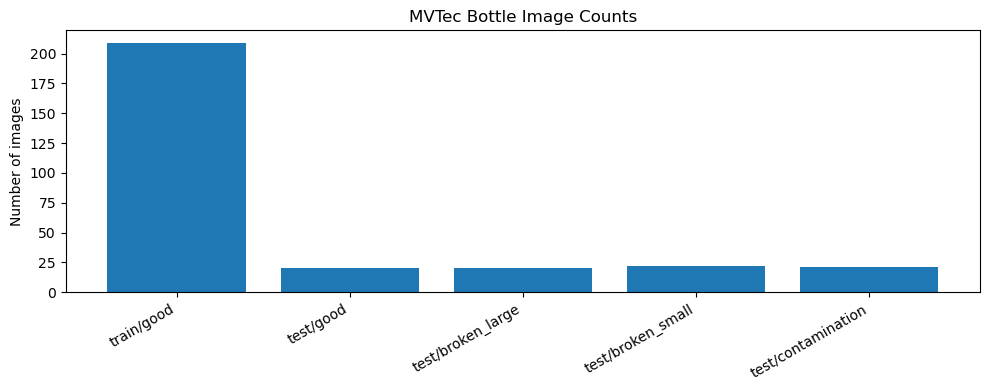

In [4]:
image_counts = counts_df[counts_df["type"] == "image"].copy()

if image_counts["count"].sum() == 0:
    print("No dataset images found yet. Copy the MVTec bottle folder into:")
    print(BOTTLE_DIR)
else:
    labels = image_counts["split"] + "/" + image_counts["label"]
    plt.figure(figsize=(10, 4))
    plt.bar(labels, image_counts["count"])
    plt.xticks(rotation=30, ha="right")
    plt.title("MVTec Bottle Image Counts")
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.show()

## Build Image Records

Here we create a table of image paths, labels, split, and mask paths.

This becomes the idea behind the next notebook: `05_dataset_loader.ipynb`.

In [5]:
def find_mask_path(image_path, label):
    if label == "good":
        return None

    mask_path = BOTTLE_DIR / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return mask_path if mask_path.exists() else None


records = []

train_good_dir = BOTTLE_DIR / "train" / "good"
for image_path in sorted(train_good_dir.glob("*.png")) if train_good_dir.exists() else []:
    records.append({
        "split": "train",
        "label": "good",
        "is_defective": False,
        "image_path": str(image_path),
        "mask_path": None,
    })

test_dir = BOTTLE_DIR / "test"
for label_dir in sorted(test_dir.iterdir()) if test_dir.exists() else []:
    if not label_dir.is_dir():
        continue

    label = label_dir.name
    for image_path in sorted(label_dir.glob("*.png")):
        records.append({
            "split": "test",
            "label": label,
            "is_defective": label != "good",
            "image_path": str(image_path),
            "mask_path": str(find_mask_path(image_path, label)) if find_mask_path(image_path, label) else None,
        })

records_df = pd.DataFrame(records)
print("Total records:", len(records_df))
records_df.head()

Total records: 292


,split,label,is_defective,image_path,mask_path
0,train,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN
1,train,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN
2,train,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN
3,train,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN
4,train,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN


## Display Sample Images

This cell displays one image from each class if available.

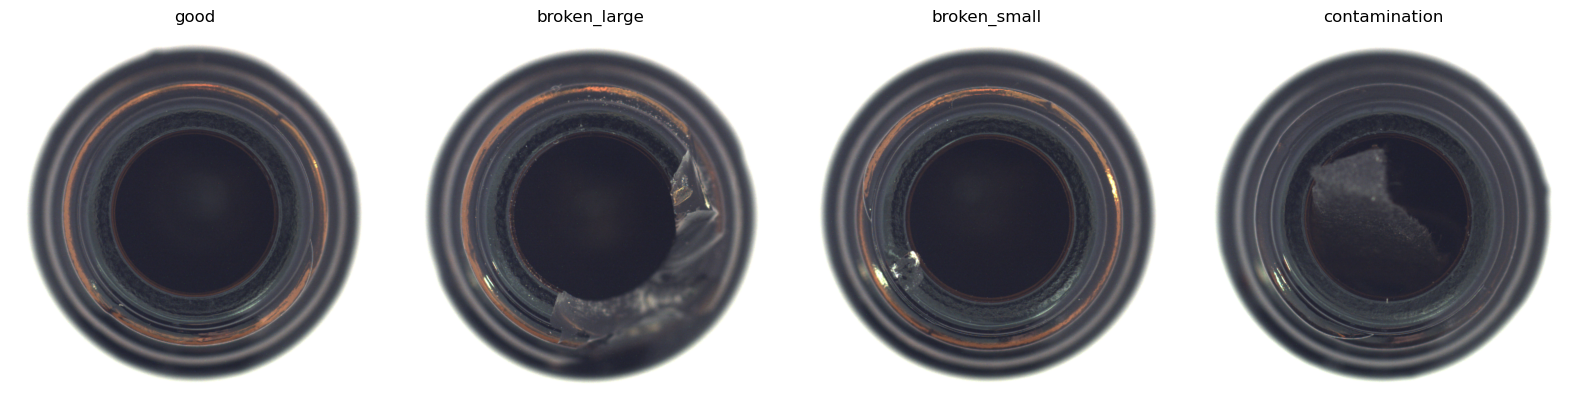

In [6]:
def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def show_sample_grid(records_df):
    if records_df.empty:
        print("No records available yet. Add the dataset first.")
        return

    labels = ["good", "broken_large", "broken_small", "contamination"]
    samples = []

    for label in labels:
        subset = records_df[records_df["label"] == label]
        if subset.empty:
            continue
        row = subset.iloc[0]
        samples.append((label, Path(row["image_path"])))

    if not samples:
        print("No sample images found.")
        return

    fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
    if len(samples) == 1:
        axes = [axes]

    for ax, (label, path) in zip(axes, samples):
        ax.imshow(read_rgb(path))
        ax.set_title(label)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_grid(records_df)

## Display Defect Image With Ground Truth Mask

Ground truth masks mark where the defect is located.

This is useful for evaluating heatmaps and localization quality.

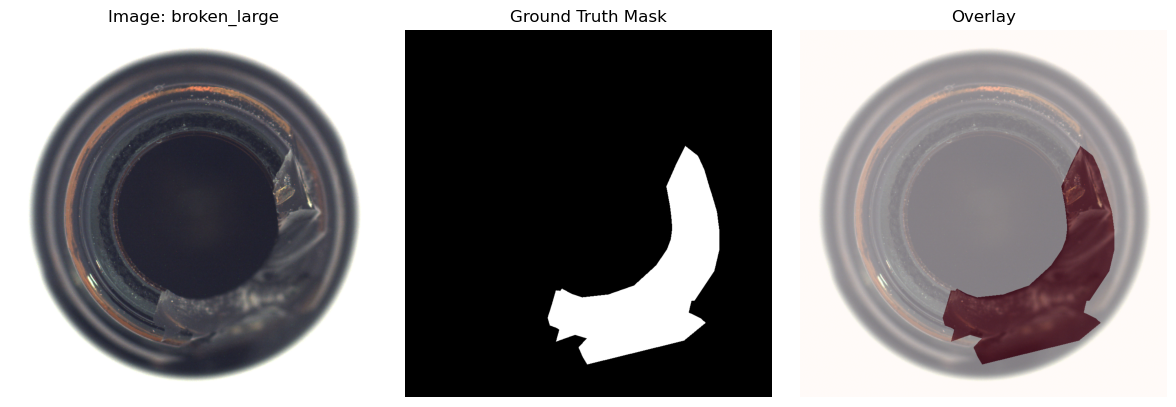

In [7]:
def show_defect_with_mask(records_df):
    if records_df.empty:
        print("No records available yet. Add the dataset first.")
        return

    defect_rows = records_df[(records_df["is_defective"] == True) & (records_df["mask_path"].notna())]
    if defect_rows.empty:
        print("No defect image with mask found yet.")
        return

    row = defect_rows.iloc[0]
    image = read_rgb(Path(row["image_path"]))
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(f"Image: {row['label']}")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground Truth Mask")

    axes[2].imshow(image)
    axes[2].imshow(mask, cmap="Reds", alpha=0.45)
    axes[2].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_defect_with_mask(records_df)

## Important Project Understanding

For anomaly detection:

- Training uses mostly or only `train/good` images.
- Testing uses `test/good` and defective test folders.
- The model predicts whether an image is normal or anomalous.
- Heatmaps show suspicious regions.
- Ground truth masks help evaluate whether heatmaps locate defects correctly.

For defect classification:

- Labels are `good`, `broken_large`, `broken_small`, and `contamination`.
- This can be trained separately after defect detection works.

## Summary

You now understand the MVTec bottle dataset:

- `train/good` contains normal training images
- `test/good` contains normal test images
- defect folders contain abnormal test images
- `ground_truth` contains defect masks
- dataset records need image path, label, split, defective flag, and mask path

Next notebook: `05_dataset_loader.ipynb`.